# Lab: Comparing Distributions Across Groups

New York City residents can use 311 to report potholes, cave-ins, failed street repairs, and other street conditions. Comparing the daily volume of these requests can help a city describe where reported demand for street-condition services was greatest.

Use the reproducible analysis workflow:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

- use Pandas datetime and string methods to prepare categories;
- use `groupby()`, `.size()`, and `reset_index()` to create daily counts;
- summarize a quantitative feature within groups;
- compare distributions with histograms, box plots, and violin plots;
- interpret center, spread, shape, overlap, and unusual values; and
- distinguish reported request volume from the underlying number of street problems.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The dataset was prepared from NYC Open Data's [*311 Service Requests from 2020 to Present*](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9). It contains 70,198 requests created during 2025 with the complaint type `Street Condition`. Rows assigned to an unspecified borough were excluded, and the four features below were retained. Each row represents one service request, not one unique street problem.

| Feature | Description |
| --- | --- |
| `request_id` | Identifier assigned to the 311 service request |
| `created_date` | Date and time when 311 created the request |
| `borough` | Borough assigned to the request |
| `descriptor` | More specific kind of street condition |

The dataset has no missing values in the retained features and was downloaded on August 13, 2026. Request counts may reflect borough population, street mileage, construction activity, awareness of 311, access to the service, and willingness to report. Therefore, borough comparisons describe **reported request volume**; they do not directly measure street quality or government performance.


# Guided analysis

## Step 1: Question

> **How did the daily number of reported street-condition requests differ across New York City's five boroughs in 2025?**


## Step 2: Data

### Import the libraries

Import Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [1]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read the data

Read `data/nyc_311_street_conditions_2025.csv` into a DataFrame named `requests`. Use `parse_dates=["created_date"]` so Pandas converts the CSV's text timestamps into datetime values while loading the file.


In [2]:
# Write your code here.
requests = pd.read_csv('data/nyc_311_street_conditions_2025.csv', parse_dates=['created_date'])

### Preview the data

Display the first and last five rows.


In [3]:
# Write your code here.
requests.head()

,request_id,created_date,borough,descriptor
0,63575321,2025-01-01 02:27:33,BROOKLYN,Pothole
1,63585580,2025-01-01 02:31:08,QUEENS,Pothole
2,63590681,2025-01-01 02:39:44,BROOKLYN,Dumpster - Construction Waste
3,63580421,2025-01-01 02:55:52,QUEENS,Pothole
4,63605103,2025-01-01 04:20:00,BROOKLYN,Wear & Tear


In [4]:
requests.tail()

,request_id,created_date,borough,descriptor
70193,67353473,2025-12-31 22:26:49,STATEN ISLAND,Pothole
70194,67346881,2025-12-31 22:27:34,STATEN ISLAND,Pothole
70195,67352385,2025-12-31 22:28:43,STATEN ISLAND,Cave-in
70196,67350032,2025-12-31 22:53:19,MANHATTAN,Defective Hardware
70197,67348685,2025-12-31 23:39:14,QUEENS,Pothole


### Inspect the DataFrame

Display its stored data types and missing-value counts.


In [5]:
# Write your code here.
requests.info()

<class 'pandas.DataFrame'>
RangeIndex: 70198 entries, 0 to 70197
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   request_id    70198 non-null  int64         
 1   created_date  70198 non-null  datetime64[us]
 2   borough       70198 non-null  str           
 3   descriptor    70198 non-null  str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 3.4 MB


In [6]:
requests.isnull().sum()

request_id      0
created_date    0
borough         0
descriptor      0
dtype: int64

**Complete the table using the data dictionary and your inspection results.** Classify each feature as categorical, quantitative, or temporal.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `request_id` | categorical | int64 | 0 |
| `created_date` | time | datetime64[us] | 0 |
| `borough` | categorical | string | 0 |
| `descriptor` | categorical | string | 0 |


**What does one row represent?**

Your answer: Each row represents a request to 311 for some type of road repair in a borough. It doesn't represent a "unique street problem."


### Predict


**Which borough do you predict will have the greatest typical number of reported street-condition requests per day? What informed your prediction?**

Your answer: As someone who grew up in the Bronx, I predict Brooklyn has the highest request rate. It is the city's most populated borough.


## Step 3: Operation


### Make the borough names human-readable

The source stores borough names in all capital letters. **Title case** capitalizes the first letter of each word and writes the remaining letters in lowercase. For example, `STATEN ISLAND` becomes `Staten Island`.

Use `.str.title()` to convert every value in `requests["borough"]` to title case and save the result back into the same feature.


In [7]:
# Write your code here.
requests['borough'] = requests['borough'].str.title()
requests.head()

,request_id,created_date,borough,descriptor
0,63575321,2025-01-01 02:27:33,Brooklyn,Pothole
1,63585580,2025-01-01 02:31:08,Queens,Pothole
2,63590681,2025-01-01 02:39:44,Brooklyn,Dumpster - Construction Waste
3,63580421,2025-01-01 02:55:52,Queens,Pothole
4,63605103,2025-01-01 04:20:00,Brooklyn,Wear & Tear


**What roles do `.str` and `.title()` play in this statement?**

Your answer: '.str' exposes string methods for every element in borough, while 'title' capitalize the first letter and writes the rest of the letters as lowercase of each word


### Create a calendar date

Create `requests["date"]` with `requests["created_date"].dt.normalize()`. The `.dt` accessor opens Pandas' datetime tools, and `.normalize()` sets the time in every value to midnight while preserving its calendar date.


In [8]:
# Write your code here.
requests['date'] = requests['created_date'].dt.normalize()

requests.head()

,request_id,created_date,borough,descriptor,date
0,63575321,2025-01-01 02:27:33,Brooklyn,Pothole,2025-01-01
1,63585580,2025-01-01 02:31:08,Queens,Pothole,2025-01-01
2,63590681,2025-01-01 02:39:44,Brooklyn,Dumpster - Construction Waste,2025-01-01
3,63580421,2025-01-01 02:55:52,Queens,Pothole,2025-01-01
4,63605103,2025-01-01 04:20:00,Brooklyn,Wear & Tear,2025-01-01


### Count requests for each borough and date

Create a DataFrame named `daily_requests` with this sequence:

1. group `requests` by `date` and `borough`;
2. use `.size()` to count rows in every group; and
3. use `.reset_index(name="request_count")` to return a DataFrame whose count column is named `request_count`.

Display the first five rows.


In [9]:
# Write your code here.
daily_requests = (
    requests.groupby(['date', 'borough'])
    .size()
    .reset_index(name='request_count')
)

daily_requests.head()

,date,borough,request_count
0,2025-01-01,Bronx,33
1,2025-01-01,Brooklyn,64
2,2025-01-01,Manhattan,14
3,2025-01-01,Queens,70
4,2025-01-01,Staten Island,8


In [10]:

requests.groupby(['created_date', 'borough']).size().reset_index(name='request_count')




,created_date,borough,request_count
0,2025-01-01 02:27:33,Brooklyn,1
1,2025-01-01 02:31:08,Queens,1
2,2025-01-01 02:39:44,Brooklyn,1
3,2025-01-01 02:55:52,Queens,1
4,2025-01-01 04:20:00,Brooklyn,1
...,...,...,...
68789,2025-12-31 22:26:49,Staten Island,1
68790,2025-12-31 22:27:34,Staten Island,1
68791,2025-12-31 22:28:43,Staten Island,1
68792,2025-12-31 22:53:19,Manhattan,1


**What does one row of `daily_requests` represent? How is that different from one row of `requests`?**

Your answer: daily_requests represents the total number of 311 requests per borough on a given day while requests represents each individual request 


**Why did we remove the time before grouping and counting the requests?** As a hint, try repeating the calculation with `created_date` in place of `date` and inspect the result.

Your answer: 'created_date' resulted in the requests_count treating each time increment as a unique group while 'date' allowed for a grouping of each day.


### Set the borough order

Create `borough_order` containing the five borough names in alphabetical order.


In [11]:
# Write your code here.
borough_order = ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']

### Calculate the mean daily request count

Create `borough_summary` by grouping `daily_requests` by `borough`, selecting `request_count`, calculating the mean, and using `.reindex(borough_order)`.


In [12]:
# Write your code here.
borough_summary = daily_requests.groupby('borough')['request_count'].mean().reindex(borough_order)

borough_summary

borough
Bronx            19.060274
Brooklyn         50.345205
Manhattan        33.936986
Queens           71.180822
Staten Island    17.800000
Name: request_count, dtype: float64

**Why is comparing only these means incomplete?**

Your answer: Looking only at means can hide variance and the shape of distribution. We can't see if that average is being skewed by extreme outliers such as the impact of snow removal on road damage.


## Step 4: Check


### Check borough-date coverage

Count the number of rows for each borough in `daily_requests`, then use `.reindex(borough_order)`.


In [13]:
# Write your code here.
daily_requests.value_counts().reindex(borough_order)

Bronx           NaN
Brooklyn        NaN
Manhattan       NaN
Queens          NaN
Staten Island   NaN
Name: count, dtype: float64

**Does every borough have a count for all 365 dates?**

Your answer: Yes


**What would it mean if one or more boroughs had a count of fewer than 365 rows?**

Your answer: It could mean either no requests were made on the missing day(s) or if they were, they weren't recorded in our dataset


### Check the calculated data

Display missing-value counts for `date`, `borough`, and `request_count`. Then use `.describe()` to summarize `request_count` within each borough and put the boroughs in `borough_order`.


In [14]:
# Write your code here.
display(daily_requests[['date', 'borough', 'request_count']].isnull().sum())

daily_requests.groupby('borough')['request_count'].describe().reindex(borough_order)

date             0
borough          0
request_count    0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,365.0,19.060274,9.238398,1.0,12.0,18.0,25.0,48.0
Brooklyn,365.0,50.345205,21.132529,6.0,33.0,51.0,65.0,113.0
Manhattan,365.0,33.936986,14.683432,2.0,23.0,33.0,43.0,91.0
Queens,365.0,71.180822,30.362103,11.0,47.0,70.0,89.0,215.0
Staten Island,365.0,17.800000,10.095206,1.0,10.0,17.0,24.0,66.0


**Are any calculated values missing or impossible?**

Your answer: No


**Would a zero necessarily be impossible in another 311 dataset?**

Your answer: No, there's always the possibility nothing is reported. I doubt potholes were a major concern during catastrophies like 9/11.

## Step 5: Evidence


### Create overlapping histograms

Use `sns.histplot()` with:

- `data=daily_requests`;
- `x="request_count"`;
- `hue="borough"` and `hue_order=borough_order`;
- `element="step"`;
- layered histograms;
- `alpha=0.45`; and
- the `"deep"` palette.

Capitalize the legend title and add a question-focused title and descriptive axis labels. Label the y-axis `Number of days`.


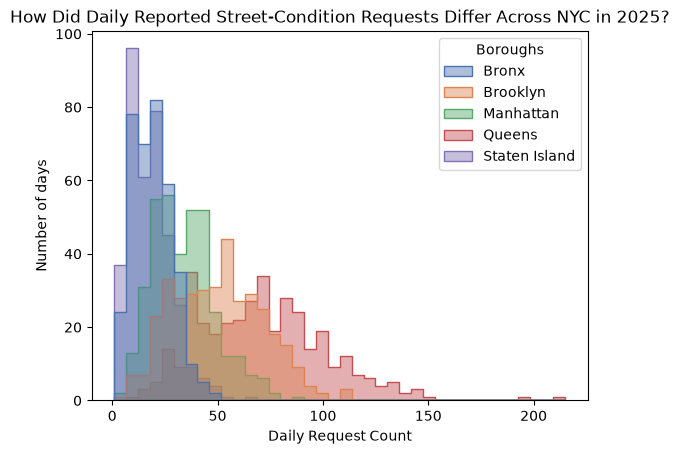

In [15]:
# Write your code here.
sns.histplot(data=daily_requests,
             x='request_count',
             hue='borough',
             hue_order=borough_order,
             element='step',
             multiple='layer',
             alpha=0.45,
             palette='deep'
)

plt.title('How Did Daily Reported Street-Condition Requests Differ Across NYC in 2025?')
plt.xlabel('Daily Request Count')
plt.ylabel('Number of days')
plt.gca().get_legend().set_title('Boroughs')
plt.show()

**What does the histogram reveal, and what makes the boroughs easy or difficult to compare?**

Your answer: It shows that daily requests are right-skewed across all boroughs. Queens' distribution was varied with more days where daily request counts exceeded 100 per day while Staten Island seems more concentrated below 50 per day. However, the details are lost with all the boroughs overlapping making it hard to pinpoint specific bins especially between 0 and 100 daily requests where the bulk of the data rests.


### Create a box plot

Put `request_count` on the x-axis and `borough` on the y-axis. Use `borough_order`, the named color `"mediumseagreen"`, and descriptive labels.


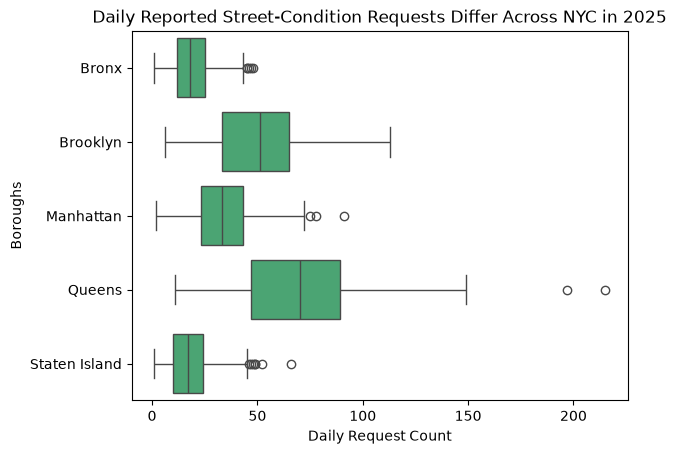

In [16]:
# Write your code here.
sns.boxplot(data=daily_requests,
            x='request_count',
            y='borough',
            order=borough_order,
            color='mediumseagreen'
            )
plt.title('Daily Reported Street-Condition Requests Differ Across NYC in 2025')
plt.xlabel('Daily Request Count')
plt.ylabel('Boroughs')
plt.show()

**What differences among boroughs are easier to see in the box plot than in the histogram?**

Your answer: Since each borough gets its own visual, it's much easier to see the spread. It's also interesting how similar Bronx and Staten Island's truly are. That was less pronounced in the histogram.


### Create a violin plot

Use the same x feature, y feature, and order. Change only the plot color to `"mediumpurple"` in addition to the required data mappings and order.


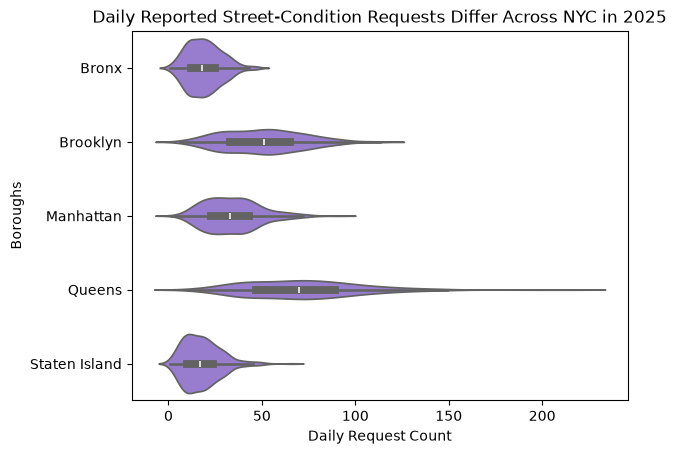

In [17]:
# Write your code here.
sns.violinplot(data=daily_requests,
            x='request_count',
            y='borough',
            order=borough_order,
            color='mediumpurple'
            )
plt.title('Daily Reported Street-Condition Requests Differ Across NYC in 2025')
plt.xlabel('Daily Request Count')
plt.ylabel('Boroughs')
plt.show()

**What does the violin plot add to the comparison?**

Your answer: The shape of distribution is clearer with the violin plot. I can see where daily requests are more concentrated in a more detailed fashion. Skewness is much easier to see too.


**Which of the three figures most clearly compares daily request counts among boroughs? Explain your choice.**

Your answer: The box plot does wonders to mitigate the visual clutter of the histogram. However, the violin's ability to show daily request concentration would win out in answering the research question.


## Step 6: Conclusion


**What conclusion about borough differences is supported by the 2025 data?**

Your answer: Brooklyn and Queens were by far the boroughs with the most requests per day. Their shapes are similar except for Queens' extreme outliers over 200 requests. Bronx and Staten Island are almost identical with the bulk clustered around their medians. Manhattan is the most uniquely shaped and sits right between the other two groups. My prediction of Brooklyn was wrong as Queens' median is much higher.


## Step 7: Limitation


**Why do these request counts not directly measure the number of street problems or borough performance?**

Your answer: The same street problem could be reported by multiple people. Unreported problems that were fixed are also possible. The data doesn't distinguish uniqueness in that respect. It also says nothing about how each borough processed a request. What if the borough was already fixing a reported issue? Too many unaccounted factors to draw meaningful conclusions about performance or actual road issues. We've all seen the "Your tax dollars at work" signs that last for months and yield questionable results.


# Your own analysis

Develop a new research question using the 311 data. Your question must compare a **quantitative feature across categorical groups**. You will probably need to calculate the quantitative feature from the original request records.

Possible grouping features include `descriptor`, month, or day of the week. You may use another meaningful categorical feature that you can create and explain.


## Step 1: Question


**Write a research question that compares a quantitative feature across categorical groups.**

Your answer: How did the daily 311 requests for street-conditions compare across different seasons in NYC in 2025?


## Step 2: Data


**Which original features will you use, and what will each row of your calculated DataFrame represent?**

Your answer: Request_id and Created_date. Each row will represent a single day in 2025 with a citywide count so I can group by season.


## Step 3: Operation

Prepare the grouping feature, calculate the quantitative feature, and save the resulting DataFrame with a meaningful name.


In [18]:
# Write your code here.
nyc_daily_requests = daily_requests.groupby('date', as_index=False)['request_count'].sum()
month_to_season = {
    1: 'Winter',
    2: 'Winter',
    12: 'Winter',
    3: 'Spring',
    4: 'Spring',
    5: 'Spring',
    6: 'Summer',
    7: 'Summer',
    8: 'Summer',
    9: 'Fall',
    10: 'Fall',
    11: 'Fall'
}
nyc_daily_requests['season'] = nyc_daily_requests['date'].dt.month.map(month_to_season)

display(nyc_daily_requests.head())
display(nyc_daily_requests.tail())


,date,request_count,season
0,2025-01-01,189,Winter
1,2025-01-02,240,Winter
2,2025-01-03,136,Winter
3,2025-01-04,110,Winter
4,2025-01-05,155,Winter


,date,request_count,season
360,2025-12-27,72,Winter
361,2025-12-28,118,Winter
362,2025-12-29,200,Winter
363,2025-12-30,196,Winter
364,2025-12-31,162,Winter


**Briefly explain how your code produced the quantitative feature and comparison groups.**

Your answer: I grouped the daily_requests by 'date' and summed the request_count values to get a citywide total per day. For 'season' I used dt.month function and mapped each month to its season with month_to_season. 


## Step 4: Check

Check the calculated data for missing or impossible values, confirm that the intended groups are present, and use an appropriate numerical summary to inspect the distributions.


In [19]:
# Write your code here.
display(nyc_daily_requests['season'].value_counts())
display(nyc_daily_requests.isnull().sum())
display(nyc_daily_requests.groupby('season')['request_count'].describe())

season
Spring    92
Summer    92
Fall      91
Winter    90
Name: count, dtype: int64

date             0
request_count    0
season           0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
Fall,91.0,156.758242,54.681978,60.0,102.50,165.0,196.00,266.0
Spring,92.0,229.358696,69.810510,114.0,154.75,251.0,276.25,426.0
Summer,92.0,205.793478,69.874540,63.0,143.25,212.0,258.25,348.0
Winter,90.0,176.655556,65.839464,40.0,122.00,181.0,224.00,362.0


**What did your checks establish?**

Your answer: There are 0 null values, the min count is 40 and all seasons are accounted for


## Step 5: Evidence

Create a histogram, box plot, or violin plot that directly addresses your question. Include a clear title and descriptive axis labels.


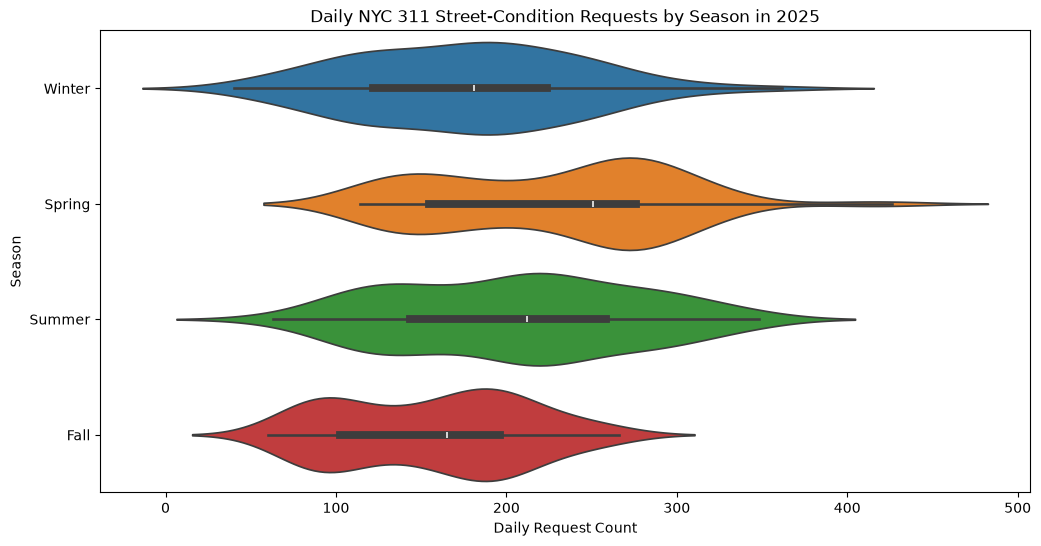

In [20]:
# Write your code here.
# sns.histplot(data=nyc_daily_requests,
#     x='request_count',
#     hue='season',
#     hue_order=['Winter', 'Spring', 'Summer', 'Fall'],
#     element='step',
# )

# sns.boxplot(
#     data=nyc_daily_requests,
#     x='season',
#     y='request_count',
#     order=['Winter', 'Spring', 'Summer', 'Fall'],
#     hue='season'
# )
plt.figure(figsize=(12,6))
sns.violinplot(
    data=nyc_daily_requests,
    y='season',
    x='request_count',
    hue='season',
)
plt.title('Daily NYC 311 Street-Condition Requests by Season in 2025')
plt.xlabel('Daily Request Count')
plt.ylabel('Season')
plt.show()                            

**What pattern in the figure provides the strongest evidence for your answer?**

Your answer: Spring showed the highest distribution of daily requests with its 251 requests/day median and max of 426. Fall came in the lowest with a median of 165. This lends credence to post Winter yielding the highest frequency of requests.


## Step 6: Conclusion


**State one conclusion that directly answers your research question.**

Your answer: With Spring leading the other seasons (median of 251 requests/day), there's strong evidence that winter climate contributed to an increase in Spring 311 requests in 2025.


## Step 7: Limitation


**State one important limitation on how your result should be interpreted.**

Your answer: The data only reflects the conditions in 2025, so a multiyear study is needed to see if this is a consistent pattern. Request counts could be a lagging indicator since winter weather could be the cause of spring request counts.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer: I used Gemini. I knew what question I wanted to ask but had trouble phrasing it. I asked for input on my initial phrasing and it made suggestions that were worded more clearly. It also suggested a general approach to phrasing the question that I noted as well for future reference.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Compare center, spread, shape, overlap, and unusual values.
- Distinguish reported request volume from actual street conditions or city performance.
- Complete the AI-use reflection.
